# Reinforcement Learning for Bitcoin Price Prediction Using TensorFlow Agents

### Libraries and Dependencies

In [2]:
import pandas as pd

In [10]:
import config
import tensorflow_agents_utils as utils
import train_dqn


### Load Data

In [4]:
source_df = utils.ingest_bitcoin_data()

2025-05-18 01:36:52,008 - tensorflow_agents_utils - INFO - Loading data for BTC-USD from 2014-09-17 to 2025-04-29
2025-05-18 01:36:52,547 - tensorflow_agents_utils - INFO - Fetching data for BTC-USD from 2014-09-17 to 2025-04-29
2025-05-18 01:36:52,549 - tensorflow_agents_utils - INFO - Data shape: (3877, 7)
2025-05-18 01:36:52,552 - tensorflow_agents_utils - INFO - DataFrame timezone: UTC
2025-05-18 01:36:52,560 - tensorflow_agents_utils - INFO - Data shape after feature calculation: (3858, 8)
2025-05-18 01:36:52,561 - tensorflow_agents_utils - INFO - Ingestion complete: features calculated
2025-05-18 01:36:52,616 - tensorflow_agents_utils - INFO - Data saved to data/raw_data.csv
2025-05-18 01:36:52,618 - tensorflow_agents_utils - INFO - Data saved to data/raw_data.csv
2025-05-18 01:36:52,624 - tensorflow_agents_utils - INFO - Train start: 2014-09-17 00:00:00+00:00, Validation start: 2022-02-21 00:00:00+00:00, Test start: 2024-01-01 00:00:00+00:00
2025-05-18 01:36:52,627 - tensorflow_

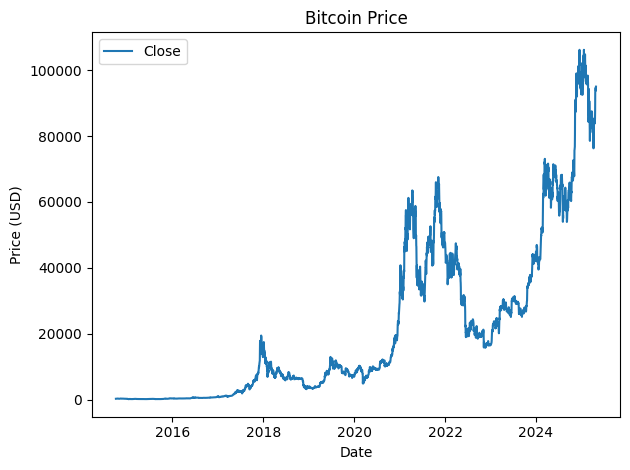

In [5]:
utils.plot_series(
    source_df,
    title="Bitcoin Price",
    y_col="Close",
    x_col="Date",
    xlabel="Date",
    ylabel="Price (USD)",
)

In [6]:
train_df = pd.read_csv(
    config.TRAIN_DATA_PATH,
)

validation_df = pd.read_csv(
    config.VALIDATION_DATA_PATH,
)

test_df = pd.read_csv(
    config.TEST_DATA_PATH,
)

# Calculate the normalization parameters only from the training data
normalize_params = utils.calculate_normalization_params(
    train_df, ["Log_Returns", "Price_SMA_20", "Volume_SMA_20", "Volume"]
)
# Normalize the training, validation, and test data
train_df, validation_df, test_df = utils.normalize_data(
    [train_df, validation_df, test_df], normalize_params
)

2025-05-18 01:36:53,018 - tensorflow_agents_utils - INFO - Column Log_Returns - Mean: 0.0017761469596693997, Std: 0.0391157071475617
2025-05-18 01:36:53,020 - tensorflow_agents_utils - INFO - Column Price_SMA_20 - Mean: 11264.945511346648, Std: 15992.657204566458
2025-05-18 01:36:53,022 - tensorflow_agents_utils - INFO - Column Volume_SMA_20 - Mean: 14729809890.420073, Std: 18544754381.717125
2025-05-18 01:36:53,024 - tensorflow_agents_utils - INFO - Column Volume - Mean: 14806241602.25232, Std: 20044534218.415874
2025-05-18 01:36:53,034 - tensorflow_agents_utils - INFO - Data normalization complete. Data shapes: [(2695, 9), (679, 9), (484, 9)]


In [7]:
train_df = train_df[["Close", "Log_Returns", "Price_SMA_20", "Volume_SMA_20", "Volume"]]
validation_df = validation_df[
    ["Close", "Log_Returns", "Price_SMA_20", "Volume_SMA_20", "Volume"]
]
test_df = test_df[["Close", "Log_Returns", "Price_SMA_20", "Volume_SMA_20", "Volume"]]
utils.save_to_csv(train_df, config.NORM_TRAIN_DATA_PATH)
utils.save_to_csv(validation_df, config.NORM_VALIDATION_DATA_PATH)
utils.save_to_csv(test_df, config.NORM_TEST_DATA_PATH)

2025-05-18 01:36:53,119 - tensorflow_agents_utils - INFO - Data saved to data/train_data_normalized.csv


2025-05-18 01:36:53,128 - tensorflow_agents_utils - INFO - Data saved to data/validation_data_normalized.csv
2025-05-18 01:36:53,138 - tensorflow_agents_utils - INFO - Data saved to data/test_data_normalized.csv


2025-05-18 01:36:53,202 - tensorflow_agents_utils - INFO - Starting DQN Agent Training Script
2025-05-18 01:36:53,205 - tensorflow_agents_utils - INFO - Setting random seed to: 42
2025-05-18 01:36:53,206 - tensorflow_agents_utils - INFO - Creating training and evaluation environments…
2025-05-18 01:36:53,208 - tensorflow_agents_utils - INFO - Attempting to create BitcoinTradingEnv with data from: data/train_data_normalized.csv
2025-05-18 01:36:53,217 - tensorflow_agents_utils - INFO - Successfully loaded data. Shape: (2695, 6), Columns: ['Unnamed: 0', 'Close', 'Log_Returns', 'Price_SMA_20', 'Volume_SMA_20', 'Volume']
2025-05-18 01:36:53,218 - tensorflow_agents_utils - INFO - Using automatically determined feature columns for observation: ['Log_Returns', 'Price_SMA_20', 'Volume_SMA_20', 'Volume']
2025-05-18 01:36:53,220 - tensorflow_agents_utils - INFO - BitcoinTradingEnv (PyEnvironment) created successfully. Observation Spec: BoundedArraySpec(shape=(20, 5), dtype=dtype('float32'), name

Instructions for updating:
Use `tf.data.Dataset.counter(...)` instead.
Instructions for updating:
Use `as_dataset(..., single_deterministic_pass=False) instead.


2025-05-18 01:36:54,405 - tensorflow_agents_utils - INFO - Training dataset created from replay buffer: batch_size=64, num_steps_in_sample=2
2025-05-18 01:36:54,528 - tensorflow_agents_utils - INFO - Starting initial collection of experiences...
2025-05-18 01:37:00,779 - tensorflow_agents_utils - INFO - Initial collection complete. Replay buffer now contains 1000 frames.


Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.foldr(fn, elems, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.foldr(fn, elems))


2025-05-18 01:37:05,787 - tensorflow_agents_utils - INFO - Iter 200 | Step 200 | Loss 0.00005 | Eps 0.972
2025-05-18 01:37:09,588 - tensorflow_agents_utils - INFO - Iter 400 | Step 400 | Loss 0.00003 | Eps 0.943
2025-05-18 01:37:13,521 - tensorflow_agents_utils - INFO - Iter 600 | Step 600 | Loss 0.00002 | Eps 0.915
2025-05-18 01:37:17,417 - tensorflow_agents_utils - INFO - Iter 800 | Step 800 | Loss 0.00002 | Eps 0.887
2025-05-18 01:37:20,741 - tensorflow_agents_utils - INFO - Iter 1000 | Step 1000 | Loss 0.00002 | Eps 0.859
2025-05-18 01:37:45,229 - tensorflow_agents_utils - INFO - Step 1000 | Eval Avg Reward -0.71484 | Directional Acc 0.402


INFO:tensorflow:Assets written to: policy/policy_step_1000_reward_-0.71484.zip/assets


/usr/local/lib/python3.8/dist-packages/tensorflow/python/saved_model/nested_structure_coder.py:475: UserWarning: Encoding a StructuredValue with type tfp.distributions.Deterministic_ACTTypeSpec; loading this StructuredValue will require that this type be imported and registered.
  warnings.warn("Encoding a StructuredValue with type %s; loading this "
INFO:tensorflow:Assets written to: policy/policy_step_1000_reward_-0.71484.zip/assets
2025-05-18 01:37:45,711 - tensorflow_agents_utils - INFO - New best policy saved to policy/policy_step_1000_reward_-0.71484.zip
INFO:tensorflow_agents_utils:New best policy saved to policy/policy_step_1000_reward_-0.71484.zip
2025-05-18 01:37:48,316 - tensorflow_agents_utils - INFO - Iter 1200 | Step 1200 | Loss 0.00006 | Eps 0.830
INFO:tensorflow_agents_utils:Iter 1200 | Step 1200 | Loss 0.00006 | Eps 0.830
2025-05-18 01:37:52,063 - tensorflow_agents_utils - INFO - Iter 1400 | Step 1400 | Loss 0.00002 | Eps 0.802
INFO:tensorflow_agents_utils:Iter 1400 | 

INFO:tensorflow:Assets written to: policy/policy_step_10000_reward_-0.64217.zip/assets


/usr/local/lib/python3.8/dist-packages/tensorflow/python/saved_model/nested_structure_coder.py:475: UserWarning: Encoding a StructuredValue with type tfp.distributions.Deterministic_ACTTypeSpec; loading this StructuredValue will require that this type be imported and registered.
  warnings.warn("Encoding a StructuredValue with type %s; loading this "
INFO:tensorflow:Assets written to: policy/policy_step_10000_reward_-0.64217.zip/assets
2025-05-18 01:44:19,981 - tensorflow_agents_utils - INFO - New best policy saved to policy/policy_step_10000_reward_-0.64217.zip
INFO:tensorflow_agents_utils:New best policy saved to policy/policy_step_10000_reward_-0.64217.zip
2025-05-18 01:44:19,984 - tensorflow_agents_utils - INFO - Training complete.
INFO:tensorflow_agents_utils:Training complete.
2025-05-18 01:44:19,987 - tensorflow_agents_utils - INFO - Displaying training visualizations…
INFO:tensorflow_agents_utils:Displaying training visualizations…


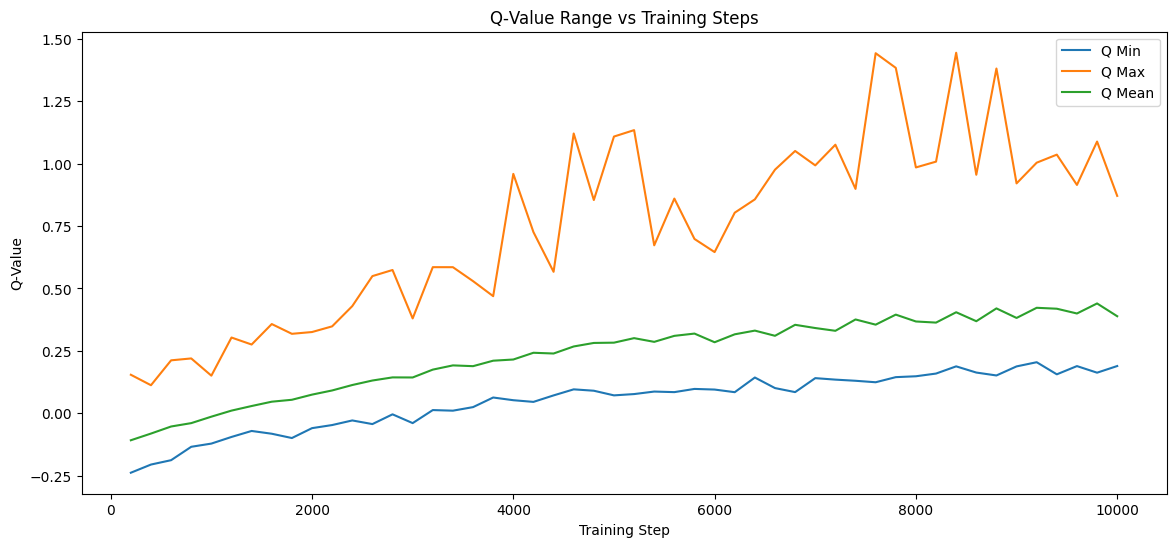

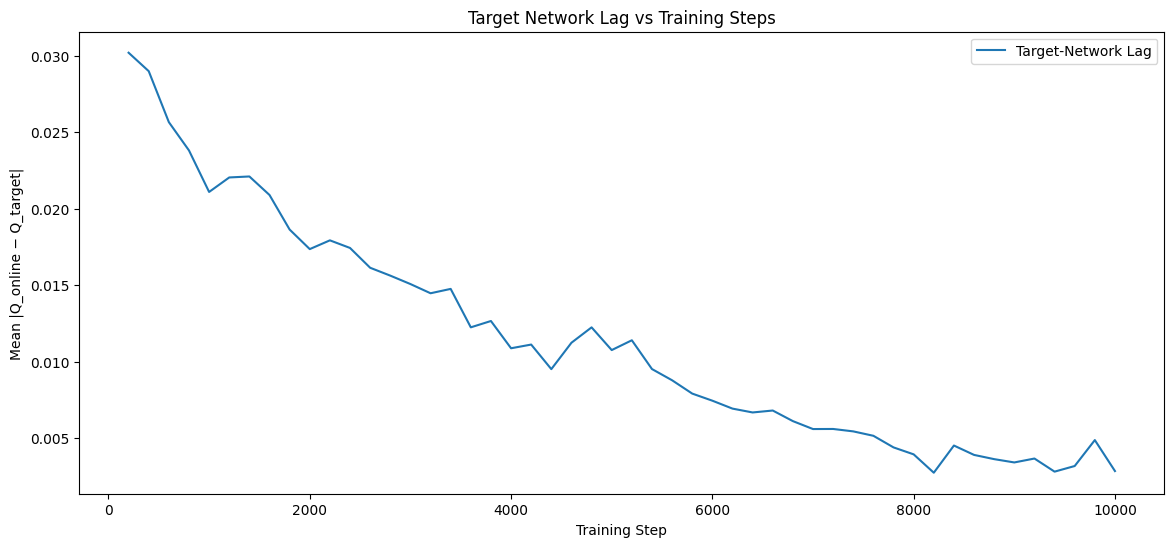

2025-05-18 01:44:20,467 - tensorflow_agents_utils - INFO - Environments closed.
INFO:tensorflow_agents_utils:Environments closed.


In [8]:
# Run train DQN
train_dqn.main(visualize=True)

2025-05-18 01:54:41,055 - tensorflow_agents_utils - INFO - Calculating Buy & Hold performance for data: data/test_data.csv
INFO:tensorflow_agents_utils:Calculating Buy & Hold performance for data: data/test_data.csv
2025-05-18 01:54:41,076 - tensorflow_agents_utils - INFO - Buy & Hold: Buying 0.236517 BTC at 42280.23 on 2024-01-01
INFO:tensorflow_agents_utils:Buy & Hold: Buying 0.236517 BTC at 42280.23 on 2024-01-01
2025-05-18 01:54:41,082 - tensorflow_agents_utils - INFO - Buy & Hold: Holding until 2025-04-28. Last close price: 94978.75. Final value: 22464.10
INFO:tensorflow_agents_utils:Buy & Hold: Holding until 2025-04-28. Last close price: 94978.75. Final value: 22464.10
2025-05-18 01:54:41,085 - tensorflow_agents_utils - INFO - Buy & Hold: Total Return: 124.64%
INFO:tensorflow_agents_utils:Buy & Hold: Total Return: 124.64%


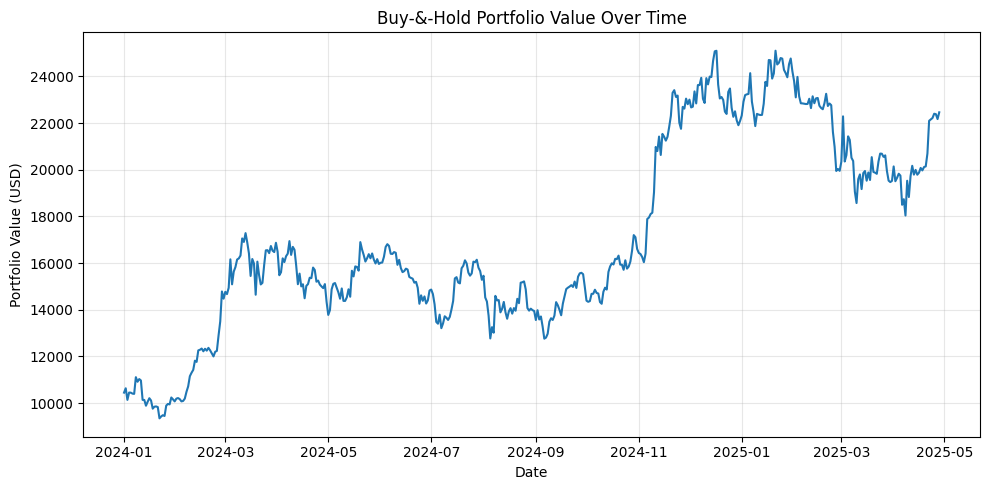

(22464.10205714476,
                     Timestamp  PortfolioValue
 0   2024-01-01 00:00:00+00:00    10446.330936
 1   2024-01-02 00:00:00+00:00    10633.330069
 2   2024-01-03 00:00:00+00:00    10134.327876
 3   2024-01-04 00:00:00+00:00    10449.308649
 4   2024-01-05 00:00:00+00:00    10445.233348
 ..                        ...             ...
 479 2025-04-24 00:00:00+00:00    22219.317907
 480 2025-04-25 00:00:00+00:00    22403.021506
 481 2025-04-26 00:00:00+00:00    22385.620867
 482 2025-04-27 00:00:00+00:00    22174.627255
 483 2025-04-28 00:00:00+00:00    22464.102057
 
 [484 rows x 2 columns],
 124.6410205714476)

In [20]:
utils.calculate_buy_and_hold_performance(
    data_path=config.TEST_DATA_PATH,
    initial_capital=10000,
    visualize=True,
)

2025-05-18 01:56:01,839 - tensorflow_agents_utils - INFO - Calculating Naive 'always_up' accuracy for data: data/test_data.csv
INFO:tensorflow_agents_utils:Calculating Naive 'always_up' accuracy for data: data/test_data.csv
2025-05-18 01:56:01,900 - tensorflow_agents_utils - INFO - Naive 'always_up' Accuracy: 51.55% (249/483 days)
INFO:tensorflow_agents_utils:Naive 'always_up' Accuracy: 51.55% (249/483 days)
2025-05-18 01:56:01,902 - tensorflow_agents_utils - INFO - Calculating Naive 'always_down' accuracy for data: data/test_data.csv
INFO:tensorflow_agents_utils:Calculating Naive 'always_down' accuracy for data: data/test_data.csv
2025-05-18 01:56:01,911 - tensorflow_agents_utils - INFO - Naive 'always_down' Accuracy: 48.45% (234/483 days)
INFO:tensorflow_agents_utils:Naive 'always_down' Accuracy: 48.45% (234/483 days)


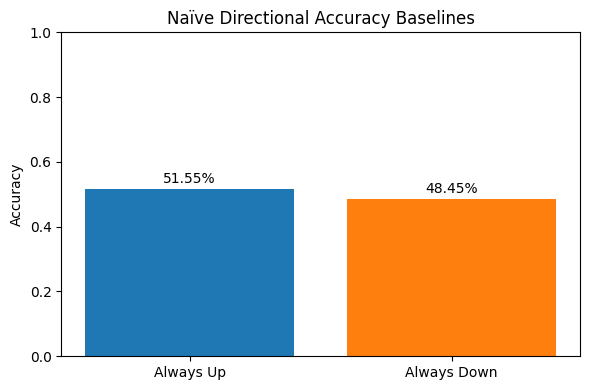

(0.515527950310559, 249, 483)

In [21]:
utils.calculate_naive_directional_accuracy(
    data_path=config.TEST_DATA_PATH,
    prediction_type="always_up",
    visualize=True,
)

In [19]:
import importlib
import tensorflow_agents_utils as utils

importlib.reload(utils)

<module 'tensorflow_agents_utils' from '/app/tensorflow_agents_utils.py'>